## Handling Missing Data
## Read the dataset context - OEWS data (uncleaned)

The OEWS dataset was gathered manually as a CSV from the U.S. Bureau of Labor Statistics' website. The data was narrowed down to specifically focus on the managerial domain.

The dataset has a number of variables - there are four variables of significance to us:

- AREA_TITLE: Area/location name, e.g. Alabama
- OCC_CODE: The Standard Occupational Classification (SOC) code, e.g. 11-0000
- OCC_TITLE: The Standard Occupational Classification (SOC) title, e.g. Management Occupations
- H_MEAN: The mean hourly wage of the worker, e.g. 61.13

**Legend**:
- `*` indicates that a wage estimate is not available
- `**` indicates an employement estimate is not available
- `#` indicates that a wage is equal to or greater than 100 dollars per hour or greater than 280,000 dollars per year
- `~` indicates a percent total less than 0.05%

In [1]:
import pandas as pd 
import numpy as np 

In [52]:
df = pd.read_excel('../Asessing/Research.xlsx')

In [53]:
df.head()

,AREA,AREA_TITLE,NAICS,NAICS_TITLE,I_GROUP,OCC_CODE,OCC_TITLE,O_GROUP,TOT_EMP,EMP_PRSE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,1,Alabama,55,Management of Companies and Enterprises,sector,00-0000,All Occupations,total,21920,0,...,35.6,56.94,79.49,35470,47040,74050,118440,165330,NaN,NaN
1,1,Alabama,55,Management of Companies and Enterprises,sector,11-0000,Management Occupations,major,4820,4.1,...,61.13,92.03,#,61600,94020,127140,191420,#,NaN,NaN
2,1,Alabama,55,Management of Companies and Enterprises,sector,11-1021,General and Operations Managers,detailed,1600,7,...,60.5,#,#,60010,78520,125850,#,#,NaN,NaN
3,1,Alabama,55,Management of Companies and Enterprises,sector,11-2021,Marketing Managers,detailed,140,13.6,...,61.13,99.23,#,65240,98680,127140,206410,#,NaN,NaN
4,1,Alabama,55,Management of Companies and Enterprises,sector,11-2022,Sales Managers,detailed,140,14.7,...,49.56,77.94,#,59390,79010,103080,162110,#,NaN,NaN


In [54]:
# Subsetting necessary data
df_sub = df[['AREA_TITLE', 'OCC_CODE', 'OCC_TITLE', 'H_MEAN']]

In [56]:
# Sum of misinterpreted nan values
df_sub.loc[df_sub['H_MEAN'].isin(['*','#'])]

,AREA_TITLE,OCC_CODE,OCC_TITLE,H_MEAN
15,Alabama,11-9141,"Property, Real Estate, and Community Associati...",*
31,Alabama,13-2052,Personal Financial Advisors,*
51,Alabama,17-3011,Architectural and Civil Drafters,*
298,Arkansas,11-9141,"Property, Real Estate, and Community Associati...",*
301,Arkansas,13-1031,"Claims Adjusters, Examiners, and Investigators",*
...,...,...,...,...
71019,New Mexico,13-0000,Business and Financial Operations Occupations,*
71103,North Dakota,47-4071,Septic Tank Servicers and Sewer Pipe Cleaners,*
71264,Tennessee,11-9021,Construction Managers,*
71293,Tennessee,53-7062,"Laborers and Freight, Stock, and Material Move...",*


In [57]:
pd.options.mode.chained_assignment = None 

## Handle Missing Data

In this step, you wil omplement the following two strategies for handling the missing data:
- Removing the rows
- Imputing the values with the column mean

Investigate how the mean of the dataset changes and the number of duplicated rows as a result. Which strategy do you see results in **the least change** to these statistics and **why**?

**Hint:** Use the `describe()` function on subsets of the dataset to identify the mean. How can the `describe()` function calculate summary statistics with missing data in the dataframe? See the [pandas documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) for more details.

In [39]:
df_sub.describe()

,AREA_TITLE,OCC_CODE,OCC_TITLE,H_MEAN
count,71508,71508,71508,71508
unique,54,596,596,6818
top,California,00-0000,All Occupations,*
freq,3223,1161,1161,536


In [58]:
# replace * and # with np.nan
df_sub["H_MEAN"] = df_sub["H_MEAN"].replace({"#":np.nan,"*":np.nan})

C:\Users\jseidl\AppData\Local\Temp\ipykernel_29784\190617920.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_sub["H_MEAN"] = df_sub["H_MEAN"].replace({"#":np.nan,"*":np.nan})


In [59]:
df_sub.describe()

,H_MEAN
count,70946.000000
mean,30.538687
std,17.569752
min,8.180000
25%,18.010000
50%,24.770000
75%,38.430000
max,172.360000


#### Remove NA Rows

In [60]:
missing_rows = df_sub.copy()

In [61]:
missing_rows.shape

(71508, 4)

In [62]:
# Drop NaN's 
missing_rows["H_MEAN"].dropna(inplace=True)

In [63]:
missing_rows.describe()

,H_MEAN
count,70946.000000
mean,30.538687
std,17.569752
min,8.180000
25%,18.010000
50%,24.770000
75%,38.430000
max,172.360000


In [64]:
missing_rows["H_MEAN"].duplicated().sum()

np.int64(64691)

### Imputing NaNs

In [65]:
impute = df_sub.copy()

In [66]:
impute["H_MEAN"] = impute["H_MEAN"].fillna(impute["H_MEAN"].mean())

In [67]:
impute.head()

,AREA_TITLE,OCC_CODE,OCC_TITLE,H_MEAN
0,Alabama,00-0000,All Occupations,42.88
1,Alabama,11-0000,Management Occupations,70.90
2,Alabama,11-1021,General and Operations Managers,72.76
3,Alabama,11-2021,Marketing Managers,69.97
4,Alabama,11-2022,Sales Managers,62.97


### Cleaning Text Data

In [68]:
import pandas as pd

txt_data = pd.read_csv('text_data.csv')

In [ ]:
# convert to lowercase 
txt_data['post'] = txt_data['post'].str.capitalize()
txt_data['post']

0     "i love technology, especially data science!"
1    "data science is a part of newer technologies"
2    "technology is a hindrance to our development"
Name: post, dtype: object

In [72]:
# Remove punctuation with regex
txt_data["post"] = txt_data['post'].str.replace('[^\w\s]','')
txt_data["post"] = txt_data['post'].str.replace('!','')
txt_data["post"] = txt_data['post'].str.replace('"','')
txt_data["post"]

0      i love technology, especially data science
1    data science is a part of newer technologies
2    technology is a hindrance to our development
Name: post, dtype: object

In [ ]:
# Create topic col 
txt_data.loc[txt_data['post'].str.contains('data science'), 
             'Topic'] = 'data science'
txt_data.head()

,sentiment,post,Topic
0,positive,"i love technology, especially data science",data science
1,neutral,data science is a part of newer technologies,data science
2,negative,technology is a hindrance to our development,NaN


In [79]:
# Tokenization / works similarily to split function
import nltk
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jseidl\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [80]:
txt_data["token"] = txt_data["post"].apply(nltk.word_tokenize)
txt_data

,sentiment,post,Topic,token
0,positive,"i love technology, especially data science",data science,"[i, love, technology, ,, especially, data, sci..."
1,neutral,data science is a part of newer technologies,data science,"[data, science, is, a, part, of, newer, techno..."
2,negative,technology is a hindrance to our development,NaN,"[technology, is, a, hindrance, to, our, develo..."


In [81]:
# Vectorize

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

words_matrix = vectorizer.fit_transform(txt_data["post"].values)
words_matrix.toarray()

array([[1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0],
       [1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0],
       [0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1]])

In [82]:
# prettyier format

counts = pd.DataFrame(words_matrix.toarray(),
                      columns=vectorizer.get_feature_names_out())
counts

,data,development,especially,hindrance,is,love,newer,of,our,part,science,technologies,technology,to
0,1,0,1,0,0,1,0,0,0,0,1,0,1,0
1,1,0,0,0,1,0,1,1,0,1,1,1,0,0
2,0,1,0,1,1,0,0,0,1,0,0,0,1,1


In [83]:
print(vectorizer.vocabulary_)

{'love': 5, 'technology': 12, 'especially': 2, 'data': 0, 'science': 10, 'is': 4, 'part': 9, 'of': 7, 'newer': 6, 'technologies': 11, 'hindrance': 3, 'to': 13, 'our': 8, 'development': 1}


### Time Series Data

In [84]:
import pandas as pd
import numpy as np

In [85]:
df = pd.read_csv('time_series_data.csv')
df.head()

,Date,Volume (in millions)
0,2018-01-01,184
1,2018-01-02,324
2,2018-01-03,551
3,2018-01-04,303
4,2018-01-05,449


In [86]:
df.describe()

,Volume (in millions)
count,1156.000000
mean,300.557958
std,169.753698
min,10.000000
25%,151.000000
50%,300.000000
75%,445.000000
max,599.000000


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  1156 non-null   object
 1   Volume (in millions)  1156 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 18.2+ KB


<Axes: xlabel='Date'>

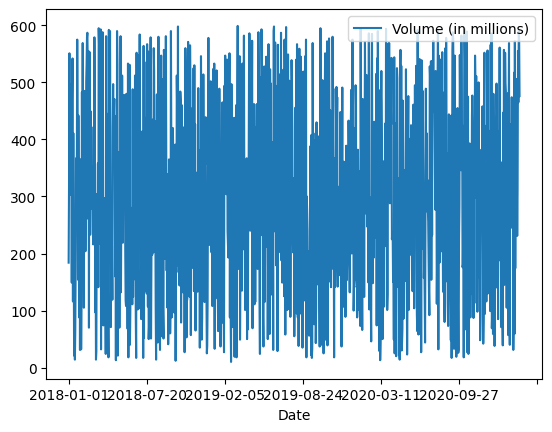

In [88]:
df.plot(x='Date',y='Volume (in millions)')

In [89]:
df['Date'] = pd.to_datetime(df['Date'])

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  1156 non-null   datetime64[ns]
 1   Volume (in millions)  1156 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 18.2 KB


In [91]:
# How much time does the data cover
df['Date'].max() - df['Date'].min()

Timedelta('1155 days 00:00:00')

In [92]:
# Create a year col 
df['Year'] = df['Date'].dt.year

In [93]:
df.head()

,Date,Volume (in millions),Year
0,2018-01-01,184,2018
1,2018-01-02,324,2018
2,2018-01-03,551,2018
3,2018-01-04,303,2018
4,2018-01-05,449,2018


In [94]:
# set index as date
df = df.set_index('Date')

In [95]:
df['day_of_week'] = df.index.dayofweek 

In [96]:
df.head()

,Volume (in millions),Year,day_of_week
Date,,,
2018-01-01,184,2018,0
2018-01-02,324,2018,1
2018-01-03,551,2018,2
2018-01-04,303,2018,3
2018-01-05,449,2018,4


### Cleaning Dirty Data Exercise

In [98]:

import pandas as pd
import numpy as np

## Dataset Context

Details of the data:

- The sensor location indicates the location where the sensor is placed and the system (A, B) it corresponds to (e.g. Entry A).
- The dates indicates the days where data was collected from the sensors (e.g. 1/5/2023).
- The numeric values indicate the pressure sensors' measurements (ranging from 0-25 bar)

In [134]:
df = pd.read_csv('pressure_sensor_data.tsv', sep='\t')
df.head()

,Sensor Location,1/5/2023,1/6/2023,1/18/2023,1/28/2023,2/6/2023,2/7/2023,2/9/2023,2/28/2023
0,Entry A,29.0,37.0,NaN,NaN,23.0,16.0,13.0,NaN
1,Area A,0.0,11.0,14.0,2.0,11.0,4.0,15.0,15.0
2,Area B,NaN,28.0,0.0,21.0,19.0,23.0,6.0,16.0
3,Entry A,6.0,NaN,4.0,5.0,NaN,NaN,11.0,3.0
4,Exit A,33.0,7.0,2.0,22.0,23.0,11.0,NaN,13.0


In [135]:
# Melting the dataset 
melted = pd.melt(df,id_vars="Sensor Location",var_name="Date",value_name="Pressure")

In [136]:
melted.head()

,Sensor Location,Date,Pressure
0,Entry A,1/5/2023,29.0
1,Area A,1/5/2023,0.0
2,Area B,1/5/2023,NaN
3,Entry A,1/5/2023,6.0
4,Exit A,1/5/2023,33.0


In [137]:
# Splitting sensor location to two columns 
melted[["Sensor Location","System"]] = melted["Sensor Location"].str.split(expand=True)

In [138]:
melted.head()

,Sensor Location,Date,Pressure,System
0,Entry,1/5/2023,29.0,A
1,Area,1/5/2023,0.0,A
2,Area,1/5/2023,NaN,B
3,Entry,1/5/2023,6.0,A
4,Exit,1/5/2023,33.0,A


In [142]:
melted.head()

,Sensor Location,Date,Pressure,System
0,Entry,1/5/2023,29.0,A
1,Area,1/5/2023,0.0,A
2,Area,1/5/2023,NaN,B
3,Entry,1/5/2023,6.0,A
4,Exit,1/5/2023,33.0,A


In [143]:
melted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sensor Location  48 non-null     object 
 1   Date             48 non-null     object 
 2   Pressure         40 non-null     float64
 3   System           48 non-null     object 
dtypes: float64(1), object(3)
memory usage: 1.6+ KB


In [144]:
melted['Date'] = pd.to_datetime(melted['Date'])

In [145]:
melted['Date'].max() - melted['Date'].min()

Timedelta('54 days 00:00:00')

## 3. Quality Issue: Validity and Accuracy

3.1 Between Jan 5th to Jan 6th, some of sensors' data for both Systems A and B were found to be corruputed due to a sudden, very high increase in temperature. 

Filter out rows where the sensors' reported data is **greater than 25 bar** into a seperate dataframe, and drop these rows from the original dataframe. 

*Hint:* Specify the invalid rows' index to drop these rows from the original dataframe.

In [146]:
ob = melted.copy()

In [147]:
ob = ob[ob["Pressure"] > 25.0]

In [148]:
ob.head()

,Sensor Location,Date,Pressure,System
0,Entry,2023-01-05,29.0,A
4,Exit,2023-01-05,33.0,A
6,Entry,2023-01-06,37.0,A
8,Area,2023-01-06,28.0,B


In [149]:
ob.index

Index([0, 4, 6, 8], dtype='int64')

In [150]:
# dropping invalid data based of ob (out of bounds) index values
melted = melted.drop(ob.index)

In [151]:
melted = melted.reset_index()

In [152]:
melted.head()

,index,Sensor Location,Date,Pressure,System
0,1,Area,2023-01-05,0.0,A
1,2,Area,2023-01-05,NaN,B
2,3,Entry,2023-01-05,6.0,A
3,5,Exit,2023-01-05,18.0,B
4,7,Area,2023-01-06,11.0,A


In [153]:
melted.describe()

,index,Date,Pressure
count,44.000000,44,36.000000
mean,25.227273,2023-01-31 00:00:00,11.583333
min,1.000000,2023-01-05 00:00:00,0.000000
25%,14.750000,2023-01-18 00:00:00,5.000000
50%,25.500000,2023-02-06 00:00:00,12.000000
75%,36.250000,2023-02-09 00:00:00,16.000000
max,47.000000,2023-02-28 00:00:00,23.000000
std,13.296028,NaN,6.983143


### Testing

In [154]:
import pandas as pd
import numpy as np
import seaborn as sns

#Read the .json file
orig_pums = pd.read_json('2021-pums.json')
orig_pums.head()

,0,1,2,3,4
0,PWGTP,WRK,SEX,SOCP,ST
1,208,0,1,119111,06
2,88,1,2,119151,06
3,55,2,1,119111,06
4,87,1,2,113121,06


In [156]:
### Cleaning code for PUMS dataset: Step 1

#Make copies of the dataframes
cleaned_pums = orig_pums.copy()

#Define the 0th row as the header
cleaned_pums.columns = cleaned_pums.iloc[0]
cleaned_pums = cleaned_pums.drop(cleaned_pums.index[0])
cleaned_pums = cleaned_pums.reset_index(drop=True)

#Keep the WRK, SEX, and SCOP variables
cleaned_pums = cleaned_pums[['WRK', 'SEX', 'SOCP']]

#Replace 0 values in WRK column with np.nan
cleaned_pums['WRK'] = cleaned_pums['WRK'].replace({'0': np.nan})

<Axes: ylabel='0'>

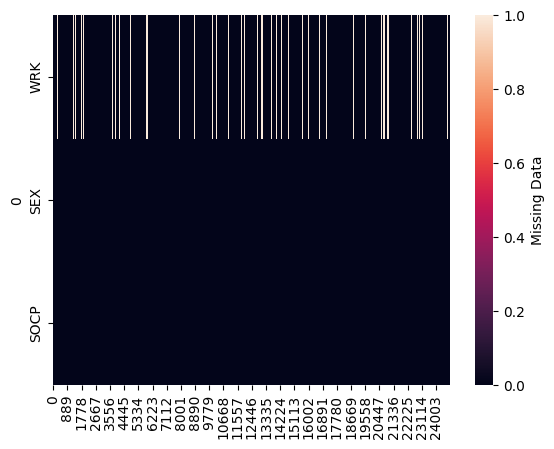

In [157]:
# heatmap of missing vals
sns.heatmap(cleaned_pums.isna().transpose(),
            cbar_kws={'label': 'Missing Data'})

In [158]:
cleaned_pums = cleaned_pums.dropna()

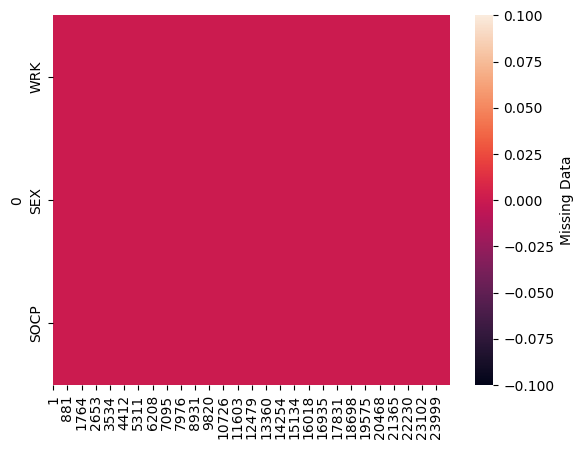

In [159]:
sns.heatmap(cleaned_pums.isna().transpose(),
            cbar_kws={'label': 'Missing Data'});

In [160]:
assert cleaned_pums.WRK.dtype == 'object'
assert cleaned_pums.SEX.dtype == 'object'
assert cleaned_pums.SOCP.dtype == 'object'

In [163]:
assert cleaned_pums.isnull().sum().sum() == 0

### Final Exercise

In [164]:
import pandas as pd
import numpy as np

In [166]:
oews_data = pd.read_excel('../Asessing/Research.xlsx')

oews_data.head()

,AREA,AREA_TITLE,NAICS,NAICS_TITLE,I_GROUP,OCC_CODE,OCC_TITLE,O_GROUP,TOT_EMP,EMP_PRSE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,1,Alabama,55,Management of Companies and Enterprises,sector,00-0000,All Occupations,total,21920,0,...,35.6,56.94,79.49,35470,47040,74050,118440,165330,NaN,NaN
1,1,Alabama,55,Management of Companies and Enterprises,sector,11-0000,Management Occupations,major,4820,4.1,...,61.13,92.03,#,61600,94020,127140,191420,#,NaN,NaN
2,1,Alabama,55,Management of Companies and Enterprises,sector,11-1021,General and Operations Managers,detailed,1600,7,...,60.5,#,#,60010,78520,125850,#,#,NaN,NaN
3,1,Alabama,55,Management of Companies and Enterprises,sector,11-2021,Marketing Managers,detailed,140,13.6,...,61.13,99.23,#,65240,98680,127140,206410,#,NaN,NaN
4,1,Alabama,55,Management of Companies and Enterprises,sector,11-2022,Sales Managers,detailed,140,14.7,...,49.56,77.94,#,59390,79010,103080,162110,#,NaN,NaN


In [167]:
cleaned_pums = pd.read_csv('../Asessing/cleaned_pums_2021.csv')
cleaned_pums.head()

,WRK,SEX,SOCP
0,1,2,119151
1,2,1,119111
2,1,2,113121
3,1,1,1110XX
4,1,1,113051


In [182]:
cleaned_wage = oews_data.copy()

In [183]:
cleaned_wage = cleaned_wage[["AREA_TITLE","OCC_CODE","OCC_TITLE","H_MEAN"]]

In [184]:
cleaned_wage.head()

,AREA_TITLE,OCC_CODE,OCC_TITLE,H_MEAN
0,Alabama,00-0000,All Occupations,42.88
1,Alabama,11-0000,Management Occupations,70.9
2,Alabama,11-1021,General and Operations Managers,72.76
3,Alabama,11-2021,Marketing Managers,69.97
4,Alabama,11-2022,Sales Managers,62.97


In [185]:
# only california
cleaned_wage = cleaned_wage[cleaned_wage["AREA_TITLE"] == 'California']

In [186]:
cleaned_wage.describe()

,AREA_TITLE,OCC_CODE,OCC_TITLE,H_MEAN
count,3223,3223,3223,3223.00
unique,1,436,436,1715.00
top,California,13-0000,Business and Financial Operations Occupations,18.89
freq,3223,22,22,13.00


In [187]:
# visual inspection and reframe index
cleaned_wage.head()

,AREA_TITLE,OCC_CODE,OCC_TITLE,H_MEAN
377,California,00-0000,All Occupations,50.16
378,California,11-0000,Management Occupations,82.61
379,California,11-1011,Chief Executives,129.7
380,California,11-1021,General and Operations Managers,87.11
381,California,11-2011,Advertising and Promotions Managers,74.67


In [188]:
cleaned_wage = cleaned_wage.reset_index(drop=True)

In [189]:
cleaned_wage.head()

,AREA_TITLE,OCC_CODE,OCC_TITLE,H_MEAN
0,California,00-0000,All Occupations,50.16
1,California,11-0000,Management Occupations,82.61
2,California,11-1011,Chief Executives,129.7
3,California,11-1021,General and Operations Managers,87.11
4,California,11-2011,Advertising and Promotions Managers,74.67


### 2.1 Completeness
There are many missing values and outliers in the wages data in the OEWS dataset, causing `H_MEAN` datatype to be object, instead of float.

- `*` indicates that a wage estimate is not available
- `#` indicates that a wage is equal to or greater than 100 dollars per hour or greater than 280,000 dollars per year

In this step, we will clean thess invalid values.

#### 2.1.1 Inspect the data types

In [190]:
cleaned_wage.dtypes

AREA_TITLE    object
OCC_CODE      object
OCC_TITLE     object
H_MEAN        object
dtype: object

In [ ]:
# replacing null identifiers with nan 
cleaned_wage["H_MEAN"] = cleaned_wage["H_MEAN"].replace({"*":np.nan,"#":np.nan})

C:\Users\jseidl\AppData\Local\Temp\ipykernel_29784\3559834862.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_wage["H_MEAN"] = cleaned_wage["H_MEAN"].replace({"*":np.nan,"#":np.nan})


In [201]:
cleaned_wage = cleaned_wage.dropna()

In [204]:
assert cleaned_wage.isnull().sum().sum() == 0

In [205]:
cleaned_wage.head()

,AREA_TITLE,OCC_CODE,OCC_TITLE,H_MEAN
0,California,00-0000,All Occupations,50.16
1,California,11-0000,Management Occupations,82.61
2,California,11-1011,Chief Executives,129.70
3,California,11-1021,General and Operations Managers,87.11
4,California,11-2011,Advertising and Promotions Managers,74.67


In [208]:
assert cleaned_wage["AREA_TITLE"].dtype == "object"
assert cleaned_wage["OCC_CODE"].dtype == "object"
assert cleaned_wage["OCC_TITLE"].dtype == "object"
assert cleaned_wage["H_MEAN"].dtype == "float64"

## 2.2 Consistency


There is an apparant lack of consistency between the OEWS and PUMS datasets with the occupation code variables, `SOCP` and `OCC_CODE`. The `OCC_CODE` variable in the OEWS dataset has hyphens as part of the code, whereas the PUMS' `SOCP` variable doesn't have this. In this step, we will address this issue.

#### 2.2.1 Add a OCC_CODE column to PUMS data

Create a new column within the PUMS dataframe called `OCC_CODE` that is a copy of the `SOCP` variable in the PUMS dataset. We'll be keeping the original `SOCP` column intact for potential cross-referencing.

In [209]:
cleaned_wage.head()

,AREA_TITLE,OCC_CODE,OCC_TITLE,H_MEAN
0,California,00-0000,All Occupations,50.16
1,California,11-0000,Management Occupations,82.61
2,California,11-1011,Chief Executives,129.70
3,California,11-1021,General and Operations Managers,87.11
4,California,11-2011,Advertising and Promotions Managers,74.67


In [210]:
cleaned_pums.head()

,WRK,SEX,SOCP
0,1,2,119151
1,2,1,119111
2,1,2,113121
3,1,1,1110XX
4,1,1,113051


In [211]:
cleaned_pums["OCC_CODE"] = cleaned_pums["SOCP"]

In [212]:
cleaned_pums.head()

,WRK,SEX,SOCP,OCC_CODE
0,1,2,119151,119151
1,2,1,119111,119111
2,1,2,113121,113121
3,1,1,1110XX,1110XX
4,1,1,113051,113051


#### 2.2.2 Clean the OCC_CODE in OEWS data

The `OCC_CODE` variable in the OEWS dataset has hyphens as part of the code, whereas the PUMS' `SOCP` variable doesn't have this. Modify the `OCC_CODE` variable within the `cleaned_wage` dataframe to remove the hyphen.

In [221]:
# using .replace to replace dash with nothing
# regex = true finds dash within a string
# if only using .replace, matches the whole string rather than parts of it 
cleaned_wage["OCC_CODE"] = cleaned_wage["OCC_CODE"].replace("-","",regex=True)

In [222]:
cleaned_wage.head()

,AREA_TITLE,OCC_CODE,OCC_TITLE,H_MEAN
0,California,000000,All Occupations,50.16
1,California,110000,Management Occupations,82.61
2,California,111011,Chief Executives,129.70
3,California,111021,General and Operations Managers,87.11
4,California,112011,Advertising and Promotions Managers,74.67


#### 2.2.3 Combine datasets 

We've cleaned the OEWS data. Now we can merge the `cleaned_pums` and `cleaned_wage` dataframes.

Drop the NA values and the unnecessary columns `Area_Title` which reports California for all values in the dataset. Drop the redundant `SOCP` variable. Finally reset the index after dropping the NA values.

*Note:* Here, we choose not to remove duplicate values - in the context of this problem statement, we value the individual counts to show the number of individuals in the sample belonging to a certain occupation (`OCC_TITLE`) / gender (`SEX`).

In [ ]:
# Mergin on occ code, right join 
combined_df = pd.merge(cleaned_pums, cleaned_wage, on=["OCC_CODE"],how='right')

In [232]:
combined_df.head()

,WRK,SEX,SOCP,OCC_CODE,AREA_TITLE,OCC_TITLE,H_MEAN
0,NaN,NaN,NaN,000000,California,All Occupations,50.16
1,NaN,NaN,NaN,110000,California,Management Occupations,82.61
2,NaN,NaN,NaN,111011,California,Chief Executives,129.70
3,1.0,1.0,111021,111021,California,General and Operations Managers,87.11
4,1.0,1.0,111021,111021,California,General and Operations Managers,87.11


In [ ]:
# dropping area title and duplicate socp col 
combined_df = combined_df.drop(columns=["AREA_TITLE", "SOCP"])

In [234]:
combined_df.head()

,WRK,SEX,OCC_CODE,OCC_TITLE,H_MEAN
0,NaN,NaN,000000,All Occupations,50.16
1,NaN,NaN,110000,Management Occupations,82.61
2,NaN,NaN,111011,Chief Executives,129.70
3,1.0,1.0,111021,General and Operations Managers,87.11
4,1.0,1.0,111021,General and Operations Managers,87.11


In [ ]:
# drop nulls 
combined_df = combined_df.dropna()

In [236]:
combined_df.head()

,WRK,SEX,OCC_CODE,OCC_TITLE,H_MEAN
3,1.0,1.0,111021,General and Operations Managers,87.11
4,1.0,1.0,111021,General and Operations Managers,87.11
5,1.0,2.0,111021,General and Operations Managers,87.11
6,1.0,2.0,111021,General and Operations Managers,87.11
7,1.0,1.0,111021,General and Operations Managers,87.11


In [237]:
combined_df = combined_df.reset_index(drop=True)

In [238]:
combined_df.head()

,WRK,SEX,OCC_CODE,OCC_TITLE,H_MEAN
0,1.0,1.0,111021,General and Operations Managers,87.11
1,1.0,1.0,111021,General and Operations Managers,87.11
2,1.0,2.0,111021,General and Operations Managers,87.11
3,1.0,2.0,111021,General and Operations Managers,87.11
4,1.0,1.0,111021,General and Operations Managers,87.11


### Store the Data

In [239]:
combined_df.to_csv('pums_and_oews_2021.csv',index=False)